# Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import math
import seaborn as sns
import pickle
import copy
from pathlib import Path
import importlib



import torch
from torch import nn, Tensor

import time
import joblib

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

from sklearn.preprocessing import StandardScaler

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from fm.seed import set_seed
import fm.data as data
import fm.model as model
import fm.training as training
import fm.physics as physics
import fm.massesPlots as massesPlots
import fm.lossPlots as lossPlots
import fm.analysis as analysis
import fm.scaling_utils as scalingUtils

In [3]:
# for the plots :
import mplhep as hep

plt.style.use(hep.style.CMS)

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 13,

    "lines.linewidth": 2,

    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",

    "legend.frameon": False,
})


# Utils

In [4]:
DATASET_TAG = "unbalanced"   # o balanced
PREPARED_DIR = "../results/prepared_splits"

SCALING_MODES = [
    "X_NONE__Y_NONE",
    "X_GLOBAL__Y_GLOBAL",
    "X_GLOBAL__Y_LOCAL",
    "X_LOCAL__Y_LOCAL",
    "X_NONE__Y_LOCAL",
]

CLASS_COL = "class"

In [41]:
# Scelgo un mode e prendo i risultati unbalanced 
BASELINE_MODE = "X_LOCAL__Y_LOCAL"   

m_dy_npz = np.load("../results/masses/masses_unbal_nonflat_mse_dy.npz")
m_h_npz  = np.load("../results/masses/masses_unbal_nonflat_mse_h.npz")

m_baseline_dy = m_dy_npz[BASELINE_MODE]
m_baseline_h  = m_h_npz[BASELINE_MODE]

# check:
print("DY baseline:", m_baseline_dy.shape)
print("H baseline:", m_baseline_h.shape)

BASELINE_MODE_2 = "X_GLOBAL__Y_LOCAL"   

m_dy_npz_2 = np.load("../results/masses/masses_unbal_nonflat_mse_dy.npz")
m_h_npz_2  = np.load("../results/masses/masses_unbal_nonflat_mse_h.npz")

m_baseline_dy_2 = m_dy_npz_2[BASELINE_MODE_2]
m_baseline_h_2  = m_h_npz_2[BASELINE_MODE_2]

# check:
print("DY baseline:", m_baseline_dy_2.shape)
print("H baseline:", m_baseline_h_2.shape)


DY baseline: (8244,)
H baseline: (25492,)
DY baseline: (8244,)
H baseline: (25492,)


In [18]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt",
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt", 
]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

met_cols = [
    "MET_logpt","MET_phi","MET_significance","MET_sumEt"
]

train_cols = (
    tau1_cols
    + tau2_cols
    + jet_cols
    + met_cols
)

y_cols = ["tau1_corr", "tau2_corr"]

In [19]:
with open("df_H_event.pkl", "rb") as f:
    df_H_event = pickle.load(f)

with open("df_DY_event.pkl", "rb") as f:
    df_DY_event = pickle.load(f)

In [20]:
# Creo i dataframe : 
#   1. All
#   2. Bilanciato

df_all = (
    pd.concat([df_DY_event, df_H_event], axis=0)
      .sample(frac=1.0, random_state=0)
      .reset_index(drop=True)
)

df_bal = data.make_balanced_df(df_all)

print("df_all:", df_all.shape)
print("df_bal:", df_bal.shape)
print("Counts df_all:", df_all["class"].value_counts().to_dict())
print("Counts df_bal:", df_bal["class"].value_counts().to_dict())

df_all: (337351, 76)
df_bal: (163894, 76)
Counts df_all: {1: 255404, 0: 81947}
Counts df_bal: {1: 81947, 0: 81947}


In [21]:
# -----------------------
# Split raw data
# -----------------------

df_all_train, df_all_val, df_all_test = data.split_df_once(df_all)
df_bal_train, df_bal_val, df_bal_test = data.split_df_once(df_bal)

print("ALL splits")
print("train:", df_all_train.shape)
print("val  :", df_all_val.shape)
print("test :", df_all_test.shape)

print()

print("BALANCED splits")
print("train:", df_bal_train.shape)
print("val  :", df_bal_val.shape)
print("test :", df_bal_test.shape)

ALL splits
train: (269880, 76)
val  : (33735, 76)
test : (33736, 76)

BALANCED splits
train: (131115, 76)
val  : (16389, 76)
test : (16390, 76)


In [22]:
mask_dy = (df_all_test["class"] == 0).to_numpy()
mask_h  = (df_all_test["class"] == 1).to_numpy()

# Trainings

In [23]:
ordered_features = [
    "jet1_logpt",
    "tau1_logpt",
    "tau2_logpt",
    "MET_sumEt",
    "tau1_dM_0",
    "jet2_logpt",
    "tau2_phi",
    "tau2_eta",
    "tau1_mass",
    "jet3_phi",
    "tau1_dM_2",
    "jet1_mass",
    "tau2_leadTkPtOverTauPt",
    "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_leadTkDeltaEta",
    "jet2_phi",
    "jet3_logpt",
    "jet2_mass",
    "tau2_dM_11",
    "tau2_dM_1",
    "tau2_leadTkDeltaPhi",
    "tau2_dM_10",
    "tau1_rawDeepTau2018v2p5VSjet",
    "tau2_ptCorrPNet",
    "tau1_charge",
    "tau2_charge",
    "MET_phi",
    "tau2_dM_0",
    "tau2_mass",
    "tau1_eta",
    "tau1_dM_11",
    "tau1_rawPNetVSjet",
    "jet1_phi",
    "tau2_dz",
    "jet3_mass",
    "jet2_eta",
    "tau1_dM_1",
    "tau1_dM_10",
    "jet1_eta",
    "tau1_dz",
    "tau2_dM_2",
    "tau2_dxy",
    "tau1_phi",
    "MET_significance",
    "tau1_dxy",
    "tau1_leadTkDeltaPhi",
    "MET_logpt",
    "tau1_leadTkPtOverTauPt",
    "tau2_rawPNetVSjet",
    "tau1_leadTkDeltaEta",
    "jet3_eta",
    "tau1_ptCorrPNet"
]

In [25]:
df_tr_1, df_va_1, df_te_1, scalers_1 = data.prepare_splits_with_scaling(
    df_train=df_all_train,
    df_val=df_all_val,
    df_test=df_all_test,
    train_cols=train_cols,
    y_cols=y_cols,
    mode="X_LOCAL__Y_LOCAL",
    class_col="class",
    x_scale_cols=ordered_features[:1],
)

df_tr_2, df_va_2, df_te_2, scalers_2 = data.prepare_splits_with_scaling(
    df_train=df_all_train,
    df_val=df_all_val,
    df_test=df_all_test,
    train_cols=train_cols,
    y_cols=y_cols,
    mode="X_LOCAL__Y_LOCAL",
    class_col="class",
    x_scale_cols=ordered_features[:2],
)

df_tr_3, df_va_3, df_te_3, scalers_3 = data.prepare_splits_with_scaling(
    df_train=df_all_train,
    df_val=df_all_val,
    df_test=df_all_test,
    train_cols=train_cols,
    y_cols=y_cols,
    mode="X_LOCAL__Y_LOCAL",
    class_col="class",
    x_scale_cols=ordered_features[:3],
)

df_tr_4, df_va_4, df_te_4, scalers_4 = data.prepare_splits_with_scaling(
    df_train=df_all_train,
    df_val=df_all_val,
    df_test=df_all_test,
    train_cols=train_cols,
    y_cols=y_cols,
    mode="X_LOCAL__Y_LOCAL",
    class_col="class",
    x_scale_cols=ordered_features[:4],
)

df_tr_5, df_va_5, df_te_5, scalers_5 = data.prepare_splits_with_scaling(
    df_train=df_all_train,
    df_val=df_all_val,
    df_test=df_all_test,
    train_cols=train_cols,
    y_cols=y_cols,
    mode="X_LOCAL__Y_LOCAL",
    class_col="class",
    x_scale_cols=ordered_features[:5],
)

df_tr_25, df_va_25, df_te_25, scalers_25 = data.prepare_splits_with_scaling(
    df_train=df_all_train,
    df_val=df_all_val,
    df_test=df_all_test,
    train_cols=train_cols,
    y_cols=y_cols,
    mode="X_LOCAL__Y_LOCAL",
    class_col="class",
    x_scale_cols=ordered_features[:25],
)

df_tr_52, df_va_52, df_te_52, scalers_52 = data.prepare_splits_with_scaling(
    df_train=df_all_train,
    df_val=df_all_val,
    df_test=df_all_test,
    train_cols=train_cols,
    y_cols=y_cols,
    mode="X_LOCAL__Y_LOCAL",
    class_col="class",
    x_scale_cols=ordered_features[:52],
)

In [26]:
# Salvo
base_dir = "../results/prepared_splits/partial_local"

mode_dir_1   = os.path.join(base_dir, "X_LOCAL__Y_LOCAL__TOP1")
mode_dir_2   = os.path.join(base_dir, "X_LOCAL__Y_LOCAL__TOP2")
mode_dir_3   = os.path.join(base_dir, "X_LOCAL__Y_LOCAL__TOP3")
mode_dir_4   = os.path.join(base_dir, "X_LOCAL__Y_LOCAL__TOP4")
mode_dir_5  = os.path.join(base_dir, "X_LOCAL__Y_LOCAL__TOP5")
mode_dir_25 = os.path.join(base_dir, "X_LOCAL__Y_LOCAL__TOP25")
mode_dir_52 = os.path.join(base_dir, "X_LOCAL__Y_LOCAL__TOP52")

mode_dirs = [
    mode_dir_1,
    mode_dir_2,
    mode_dir_3,
    mode_dir_4,
    mode_dir_5,
    mode_dir_25,
    mode_dir_52,
]

for d in mode_dirs:
    os.makedirs(d, exist_ok=True)


# salvo in pkl
df_tr_1.to_pickle(os.path.join(mode_dir_1, "train.pkl"))
df_va_1.to_pickle(os.path.join(mode_dir_1, "val.pkl"))
df_te_1.to_pickle(os.path.join(mode_dir_1, "test.pkl"))
joblib.dump(scalers_1, os.path.join(mode_dir_1, "scalers.joblib"))

df_tr_2.to_pickle(os.path.join(mode_dir_2, "train.pkl"))
df_va_2.to_pickle(os.path.join(mode_dir_2, "val.pkl"))
df_te_2.to_pickle(os.path.join(mode_dir_2, "test.pkl"))
joblib.dump(scalers_2, os.path.join(mode_dir_2, "scalers.joblib"))

df_tr_3.to_pickle(os.path.join(mode_dir_3, "train.pkl"))
df_va_3.to_pickle(os.path.join(mode_dir_3, "val.pkl"))
df_te_3.to_pickle(os.path.join(mode_dir_3, "test.pkl"))
joblib.dump(scalers_3, os.path.join(mode_dir_3, "scalers.joblib"))

df_tr_4.to_pickle(os.path.join(mode_dir_4, "train.pkl"))
df_va_4.to_pickle(os.path.join(mode_dir_4, "val.pkl"))
df_te_4.to_pickle(os.path.join(mode_dir_4, "test.pkl"))
joblib.dump(scalers_4, os.path.join(mode_dir_4, "scalers.joblib"))

# TOP 5
df_tr_5.to_pickle(os.path.join(mode_dir_5, "train.pkl"))
df_va_5.to_pickle(os.path.join(mode_dir_5, "val.pkl"))
df_te_5.to_pickle(os.path.join(mode_dir_5, "test.pkl"))
joblib.dump(scalers_5, os.path.join(mode_dir_5, "scalers.joblib"))

# TOP 25
df_tr_25.to_pickle(os.path.join(mode_dir_25, "train.pkl"))
df_va_25.to_pickle(os.path.join(mode_dir_25, "val.pkl"))
df_te_25.to_pickle(os.path.join(mode_dir_25, "test.pkl"))
joblib.dump(scalers_25, os.path.join(mode_dir_25, "scalers.joblib"))

# TOP 52
df_tr_52.to_pickle(os.path.join(mode_dir_52, "train.pkl"))
df_va_52.to_pickle(os.path.join(mode_dir_52, "val.pkl"))
df_te_52.to_pickle(os.path.join(mode_dir_52, "test.pkl"))
joblib.dump(scalers_52, os.path.join(mode_dir_52, "scalers.joblib"))

['../results/prepared_splits/partial_local/X_LOCAL__Y_LOCAL__TOP52/scalers.joblib']

# Trainings

In [27]:
results = {}

configs = {
    1: mode_dir_1,
    2: mode_dir_2,
    3: mode_dir_3,
    4: mode_dir_4,
    5: mode_dir_5,
    25: mode_dir_25,
    52: mode_dir_52,
}

for k, mode_dir in configs.items():
    print(f"\nTraining TOP{k}")

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        verbose_every=10,
        loss_type="mse",
    )

    results[k] = res


Training TOP1...
[ep    1] train=3.895632  val=2.019725  best=2.019725  bad=0/30
[ep   10] train=1.902442  val=1.908341  best=1.900901  bad=3/30
[ep   20] train=1.857171  val=1.857808  best=1.857808  bad=0/30
[ep   30] train=1.777599  val=1.709661  best=1.709661  bad=0/30
[ep   40] train=1.730166  val=1.748361  best=1.651051  bad=3/30
[ep   50] train=1.602392  val=1.633128  best=1.589254  bad=1/30
[ep   60] train=1.545018  val=1.661875  best=1.518222  bad=1/30
[ep   70] train=1.514314  val=1.538067  best=1.470959  bad=8/30
[ep   80] train=2.036224  val=1.548893  best=1.464715  bad=5/30
[ep   90] train=1.496555  val=1.841824  best=1.441504  bad=2/30
[ep  100] train=1.413665  val=1.399932  best=1.376142  bad=3/30
[ep  110] train=1.393874  val=1.388472  best=1.363783  bad=2/30
[ep  120] train=1.362283  val=1.363717  best=1.352162  bad=4/30
[ep  130] train=1.337644  val=1.355812  best=1.331445  bad=1/30
[ep  140] train=1.353637  val=1.308037  best=1.308037  bad=0/30
[ep  150] train=1.3226

In [28]:
# salvo
runs_dir = "../results/runs_partial_local"
os.makedirs(runs_dir, exist_ok=True)

for k, res in results.items():
    joblib.dump(res, os.path.join(runs_dir, f"res_top{k}.joblib"))

## Predictions

In [33]:
predictions = {}

for k, res in results.items():

    print(f"Predicting TOP{k}")

    df_pred = model.predict_tau_corr_auto_new(
        df=df_all_test,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    predictions[k] = df_pred

Predicting TOP1...
Predicting TOP2...
Predicting TOP3...
Predicting TOP4...
Predicting TOP5...
Predicting TOP25...
Predicting TOP52...


In [34]:
# length check 
for k, df_pred in predictions.items():
    print(k, df_pred.shape)

1 (33736, 2)
2 (33736, 2)
3 (33736, 2)
4 (33736, 2)
5 (33736, 2)
25 (33736, 2)
52 (33736, 2)


## Masses

In [35]:
masses = {}

for k, df_pred in predictions.items():

    masses_k = physics.inv_mass_two_taus_corrected_ratio(
        df_all_test["tau1_pt_reco_corrPNet"].to_numpy(),
        df_all_test["tau1_eta"].to_numpy(),
        df_all_test["tau1_phi"].to_numpy(),
        df_all_test["tau1_mass"].to_numpy(),
        df_pred["tau1_corr_pred"].to_numpy(),

        df_all_test["tau2_pt_reco_corrPNet"].to_numpy(),
        df_all_test["tau2_eta"].to_numpy(),
        df_all_test["tau2_phi"].to_numpy(),
        df_all_test["tau2_mass"].to_numpy(),
        df_pred["tau2_corr_pred"].to_numpy(),
    )

    masses[k] = masses_k

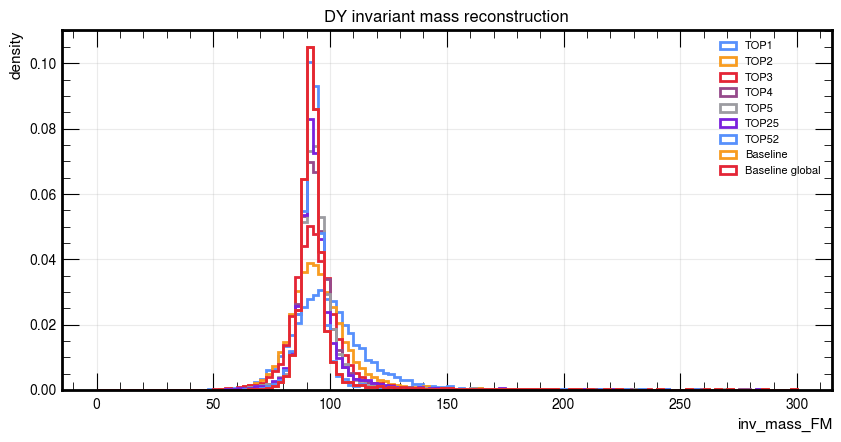

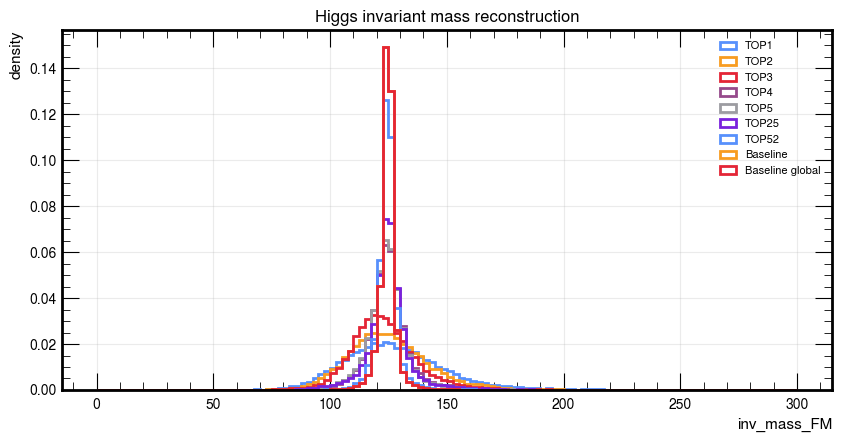

In [37]:
mask_h = df_all_test["class"] == 1
mask_dy = df_all_test["class"] == 0

masses_h = {}
masses_dy = {}

for k, m in masses.items():
    masses_h[f"TOP{k}"] = m[mask_h]
    masses_dy[f"TOP{k}"] = m[mask_dy]

masses_h["Baseline"] = m_baseline_h
masses_dy["Baseline"] = m_baseline_dy

masses_h["Baseline global"] = m_baseline_h_2
masses_dy["Baseline global"] = m_baseline_dy_2

massesPlots.plot_mass_overlay(
    masses_dy,
    title="DY invariant mass reconstruction",
    bins=120,
    range_=(0,300),
    density=True,
)

massesPlots.plot_mass_overlay(
    masses_h,
    title="Higgs invariant mass reconstruction",
    bins=120,
    range_=(0,300),
    density=True,
)

## Analysis

In [42]:
df_eval = {}

for k, m in masses.items():

    df_tmp = df_all_test.copy()
    df_tmp["m_pred"] = m

    df_eval[k] = df_tmp

SB_results = {}

for k, df_tmp in df_eval.items():

    SB_results[f"TOP{k}"] = analysis.compute_S_over_B(
        df_tmp,
        mass_col="m_pred",
        window=(110, 130),
    )

df_eval_baseline = pd.DataFrame({
    "m_pred": np.concatenate([m_baseline_dy, m_baseline_h]),
    "class": np.concatenate([
        np.zeros(len(m_baseline_dy), dtype=int),
        np.ones(len(m_baseline_h), dtype=int),
    ]),
})

df_eval_baseline_2 = pd.DataFrame({
    "m_pred": np.concatenate([m_baseline_dy_2, m_baseline_h_2]),
    "class": np.concatenate([
        np.zeros(len(m_baseline_dy_2), dtype=int),
        np.ones(len(m_baseline_h_2), dtype=int),
    ]),
})

SB_results["Baseline local"] = analysis.compute_S_over_B(
    df_eval_baseline,
    mass_col="m_pred",
    window=(110, 130),
)

SB_results["Baseline global"] = analysis.compute_S_over_B(
    df_eval_baseline_2,
    mass_col="m_pred",
    window=(110, 130),
)

df_SB = pd.DataFrame(SB_results).T
df_SB = df_SB[["N_S", "N_B", "S_over_B", "S_over_sqrtB"]]
df_SB

,N_S,N_B,S_over_B,S_over_sqrtB
TOP1,9699,1323,7.331066,266.653346
TOP2,11869,689,17.226415,452.172888
TOP3,14780,398,37.135678,740.854457
TOP4,18960,301,62.990033,1092.836232
TOP5,19328,245,78.889796,1234.820625
TOP25,19379,345,56.171014,1043.330288
TOP52,23583,135,174.688889,2029.701472
Baseline local,24179,169,143.071006,1859.923077
Baseline global,19865,1530,12.98366,507.85865


In [44]:
row_order = [
    "Baseline local",
    "TOP1",
    "TOP2",
    "TOP3",
    "TOP4",
    "TOP5",
    "TOP25",
    "TOP52",
]

df_SB = df_SB.loc[row_order]
df_SB

,N_S,N_B,S_over_B,S_over_sqrtB
Baseline local,24179,169,143.071006,1859.923077
TOP1,9699,1323,7.331066,266.653346
TOP2,11869,689,17.226415,452.172888
TOP3,14780,398,37.135678,740.854457
TOP4,18960,301,62.990033,1092.836232
TOP5,19328,245,78.889796,1234.820625
TOP25,19379,345,56.171014,1043.330288
TOP52,23583,135,174.688889,2029.701472


In [48]:
res_52_b = training.train_one_mode(
    mode_dir=mode_dir_52,
    train_cols=train_cols,
    y_cols=y_cols,
    verbose_every=10,
    loss_type="mse",
)

[ep    1] train=1.856846  val=1.695019  best=1.695019  bad=0/30
[ep   10] train=1.160128  val=1.147971  best=1.147971  bad=0/30
[ep   20] train=0.993465  val=0.994419  best=0.982155  bad=1/30
[ep   30] train=0.953366  val=0.968934  best=0.948568  bad=1/30
[ep   40] train=0.921881  val=0.922927  best=0.922927  bad=0/30
[ep   50] train=0.905678  val=0.922665  best=0.899517  bad=1/30
[ep   60] train=0.894473  val=0.889151  best=0.888643  bad=8/30
[ep   70] train=0.880123  val=0.884584  best=0.875337  bad=1/30
[ep   80] train=0.877988  val=0.880520  best=0.867008  bad=2/30
[ep   90] train=0.864999  val=0.863052  best=0.863069  bad=5/30
[ep  100] train=0.854276  val=0.857145  best=0.857145  bad=0/30
[ep  110] train=0.851704  val=0.852667  best=0.852667  bad=0/30
[ep  120] train=0.844173  val=0.844915  best=0.844915  bad=0/30
[ep  130] train=0.828133  val=0.836812  best=0.833345  bad=2/30
[ep  140] train=0.817734  val=0.833369  best=0.813856  bad=2/30
[ep  150] train=0.804210  val=0.808920  

In [49]:
df_pred_52_b = model.predict_tau_corr_auto_new(
    df=df_all_test,
    res=res_52_b,
    train_cols=train_cols,
    y_cols=y_cols,
)

In [50]:
masses_52_b = physics.inv_mass_two_taus_corrected_ratio(
    df_all_test["tau1_pt_reco_corrPNet"].to_numpy(),
    df_all_test["tau1_eta"].to_numpy(),
    df_all_test["tau1_phi"].to_numpy(),
    df_all_test["tau1_mass"].to_numpy(),
    df_pred_52_b["tau1_corr_pred"].to_numpy(),

    df_all_test["tau2_pt_reco_corrPNet"].to_numpy(),
    df_all_test["tau2_eta"].to_numpy(),
    df_all_test["tau2_phi"].to_numpy(),
    df_all_test["tau2_mass"].to_numpy(),
    df_pred_52_b["tau2_corr_pred"].to_numpy(),
)

## Results

In [51]:
m_h_52_b = masses_52_b[mask_h]
m_dy_52_b = masses_52_b[mask_dy]

df_eval_52_b = df_all_test.copy()
df_eval_52_b["m_pred"] = masses_52_b

SB_52_b = analysis.compute_S_over_B(
    df_eval_52_b,
    mass_col="m_pred",
    window=(110, 130),
)

SB_52_b

{'N_S': 24306,
 'N_B': 175,
 'S_over_B': 138.89142857142858,
 'window': (110, 130),
 'mass_col': 'm_pred',
 'S_over_sqrtB': 1837.3608961924554}

In [75]:
import fm.massesPlots as massesPlots
importlib.reload(massesPlots)

<module 'fm.massesPlots' from '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/fm/massesPlots.py'>

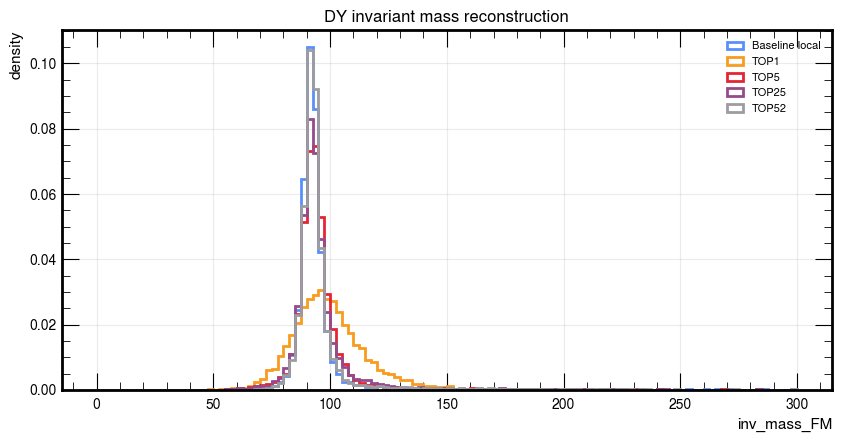

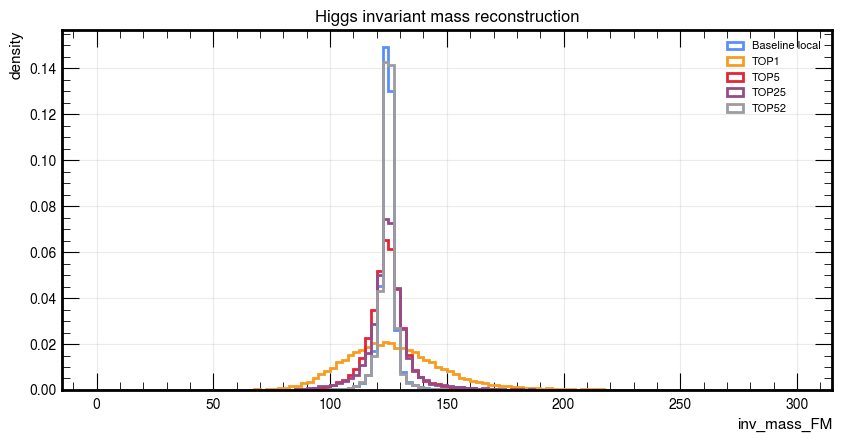

In [72]:
masses_h_plot = {
    "Baseline local": m_baseline_h,
    "TOP1": masses[1][mask_h],
    "TOP5": masses[5][mask_h],
    "TOP25": masses[25][mask_h],
    "TOP52": masses[52][mask_h],
}

masses_dy_plot = {
    "Baseline local": m_baseline_dy,
    "TOP1": masses[1][mask_dy],
    "TOP5": masses[5][mask_dy],
    "TOP25": masses[25][mask_dy],
    "TOP52": masses[52][mask_dy],
}

massesPlots.plot_mass_overlay(
    masses_dy_plot,
    title="DY invariant mass reconstruction",
    bins=120,
    range_=(0,300),
    density=True,

)

massesPlots.plot_mass_overlay(
    masses_h_plot,
    title="Higgs invariant mass reconstruction",
    bins=120,
    range_=common_range,
    density=True,
)

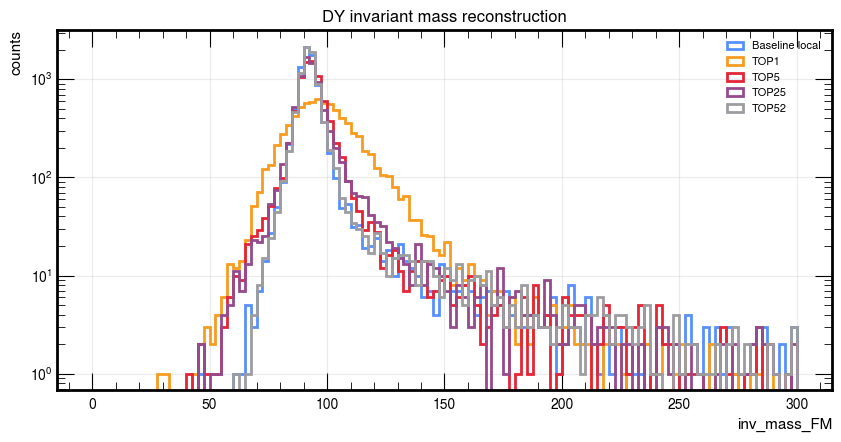

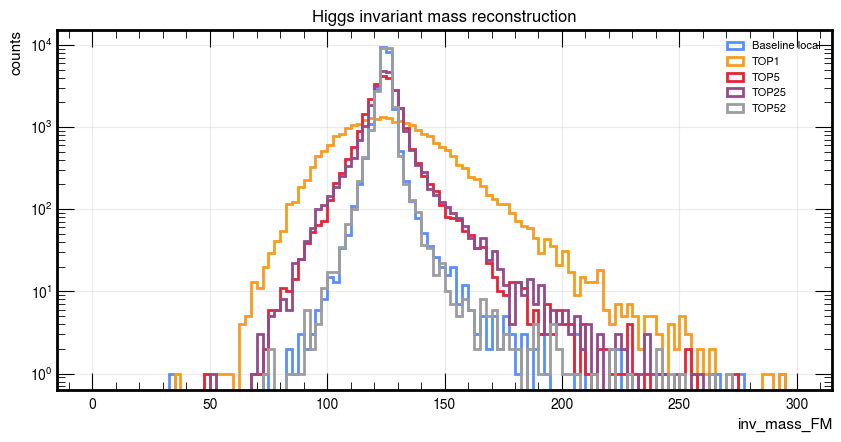

In [78]:
massesPlots.plot_mass_overlay(
    masses_dy_plot,
    title="DY invariant mass reconstruction",
    bins=120,
    range_=(0,300),
    density=False,
    logy=True,

)

massesPlots.plot_mass_overlay(
    masses_h_plot,
    title="Higgs invariant mass reconstruction",
    bins=120,
    range_=common_range,
    density=False,
    logy=True,
)

In [52]:
masses[52] = masses_52_b

In [54]:
df_eval = {}

for k, m in masses.items():
    df_tmp = df_all_test.copy()
    df_tmp["m_pred"] = m
    df_eval[k] = df_tmp

SB_results = {}

for k, df_tmp in df_eval.items():
    SB_results[f"TOP{k}"] = analysis.compute_S_over_B(
        df_tmp,
        mass_col="m_pred",
        window=(110, 130),
    )

df_SB = pd.DataFrame(SB_results).T
df_SB = df_SB[["N_S", "N_B", "S_over_B", "S_over_sqrtB"]]
df_SB

,N_S,N_B,S_over_B,S_over_sqrtB
TOP1,9699,1323,7.331066,266.653346
TOP2,11869,689,17.226415,452.172888
TOP3,14780,398,37.135678,740.854457
TOP4,18960,301,62.990033,1092.836232
TOP5,19328,245,78.889796,1234.820625
TOP25,19379,345,56.171014,1043.330288
TOP52,24306,175,138.891429,1837.360896


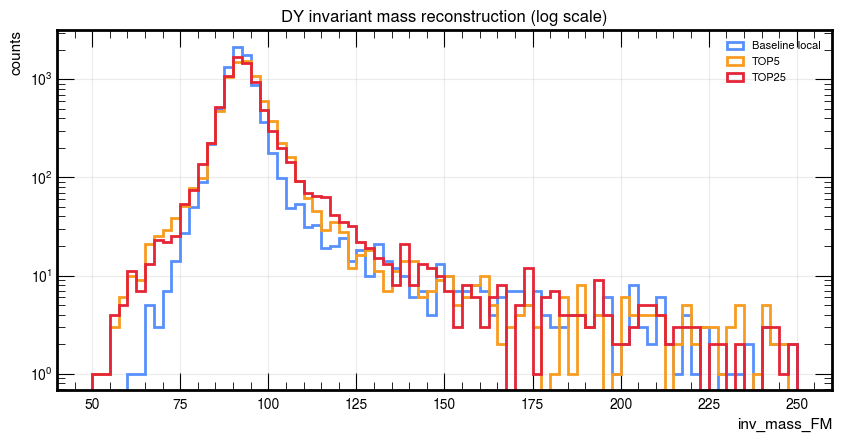

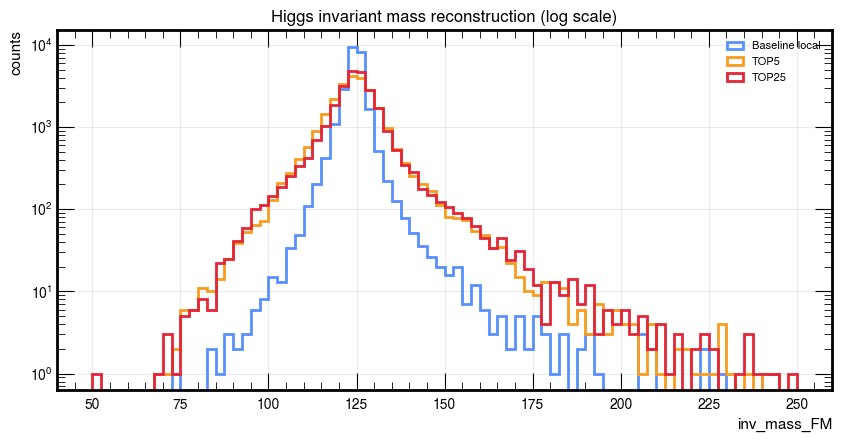

In [84]:
masses_dy_plot = {
    "Baseline local": m_baseline_dy,
    "TOP5": masses[5][mask_dy],
    "TOP25": masses[25][mask_dy],
}

massesPlots.plot_mass_overlay(
    masses_dy_plot,
    title="DY invariant mass reconstruction (log scale)",
    bins=80,
    range_=(50,250),
    density=False,
    logy=True
)

masses_h_plot = {
    "Baseline local": m_baseline_h,
    "TOP5": masses[5][mask_h],
    "TOP25": masses[25][mask_h],
}

massesPlots.plot_mass_overlay(
    masses_h_plot,
    title="Higgs invariant mass reconstruction (log scale)",
    bins=80,
    range_=(50,250),
    density=False,
    logy=True
)

# Trainings con solo tau_logpt scalato

In [85]:
x_scale_cols_tau = ["tau1_logpt", "tau2_logpt"]

df_tr_tau, df_va_tau, df_te_tau, scalers_tau = data.prepare_splits_with_scaling(
    df_train=df_all_train,
    df_val=df_all_val,
    df_test=df_all_test,
    train_cols=train_cols,
    y_cols=y_cols,
    mode="X_LOCAL__Y_LOCAL",
    class_col="class",
    x_scale_cols=x_scale_cols_tau,
)

base_dir = "../results/prepared_splits/partial_local"
mode_dir_tau = os.path.join(base_dir, "X_LOCAL__Y_LOCAL__TAU1TAU2_LOGPT")

os.makedirs(mode_dir_tau, exist_ok=True)

df_tr_tau.to_pickle(os.path.join(mode_dir_tau, "train.pkl"))
df_va_tau.to_pickle(os.path.join(mode_dir_tau, "val.pkl"))
df_te_tau.to_pickle(os.path.join(mode_dir_tau, "test.pkl"))
joblib.dump(scalers_tau, os.path.join(mode_dir_tau, "scalers.joblib"))

results = {}

print("\nTraining TAU1+TAU2 logpt local, Y local")

res_tau = training.train_one_mode(
    mode_dir=mode_dir_tau,
    train_cols=train_cols,
    y_cols=y_cols,
    verbose_every=10,
    loss_type="mse",
)

results["tau_logpt_only"] = res_tau


Training TAU1+TAU2 logpt local, Y local
[ep    1] train=3.874497  val=2.031342  best=2.031342  bad=0/30
[ep   10] train=1.809828  val=1.872460  best=1.814527  bad=1/30
[ep   20] train=1.668427  val=1.679805  best=1.679805  bad=0/30
[ep   30] train=1.545401  val=1.485630  best=1.485630  bad=0/30
[ep   40] train=1.439366  val=1.375760  best=1.375760  bad=0/30
[ep   50] train=1.432237  val=1.332639  best=1.332639  bad=0/30
[ep   60] train=1.331067  val=1.294658  best=1.283282  bad=3/30
[ep   70] train=1.304246  val=1.300737  best=1.263401  bad=3/30
[ep   80] train=1.276859  val=1.244779  best=1.241705  bad=2/30
[ep   90] train=1.245617  val=1.234794  best=1.199532  bad=1/30
[ep  100] train=1.199076  val=1.196377  best=1.177940  bad=4/30
[ep  110] train=1.181109  val=1.215336  best=1.144726  bad=5/30
[ep  120] train=1.522319  val=1.694234  best=1.134097  bad=9/30
[ep  130] train=1.137615  val=1.111358  best=1.111358  bad=0/30
[ep  140] train=3.018870  val=5.045423  best=1.111054  bad=8/30

In [99]:
# predictions
pred_tau_only = model.predict_tau_corr_auto_new(
    df=df_all_test,
    res=res_tau,
    train_cols=train_cols,
    y_cols=y_cols,
)

In [100]:
df_pred_tau = df_all_test.copy()
df_pred_tau = pd.concat([df_pred_tau, pred_tau_only], axis=1)

In [101]:
# ============================================================
# 2) Compute invariant masses
# ============================================================

m_tau = physics.inv_mass_two_taus_corrected_ratio(
    df_pred_tau["tau1_pt_reco_corrPNet"].to_numpy(),
    df_pred_tau["tau1_eta"].to_numpy(),
    df_pred_tau["tau1_phi"].to_numpy(),
    df_pred_tau["tau1_mass"].to_numpy(),
    df_pred_tau["tau1_corr_pred"].to_numpy(),
    df_pred_tau["tau2_pt_reco_corrPNet"].to_numpy(),
    df_pred_tau["tau2_eta"].to_numpy(),
    df_pred_tau["tau2_phi"].to_numpy(),
    df_pred_tau["tau2_mass"].to_numpy(),
    df_pred_tau["tau2_corr_pred"].to_numpy(),
)

In [102]:
# ============================================================
# 3) Split Higgs / DY
# ============================================================

mask_h_tau  = df_pred_tau["class"].to_numpy() == 1
mask_dy_tau = df_pred_tau["class"].to_numpy() == 0

m_tau_h  = m_tau[mask_h_tau]
m_tau_dy = m_tau[mask_dy_tau]


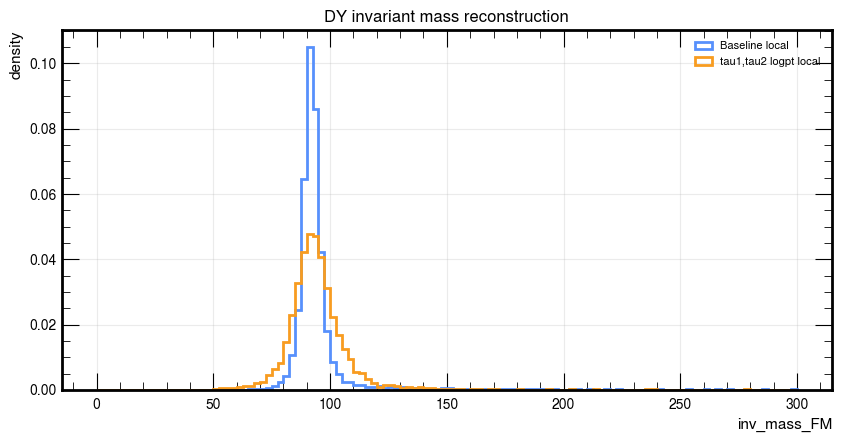

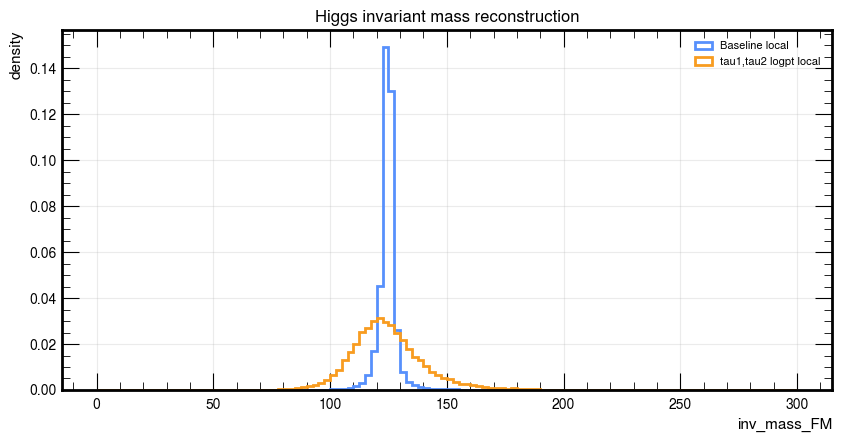

In [103]:
# ============================================================
# 4) Plot masses vs baseline
# ============================================================

masses_h_plot = {
    "Baseline local": m_baseline_h,
    "tau1,tau2 logpt local": m_tau_h,
}

masses_dy_plot = {
    "Baseline local": m_baseline_dy,
    "tau1,tau2 logpt local": m_tau_dy,
}

massesPlots.plot_mass_overlay(
    masses_dy_plot,
    title="DY invariant mass reconstruction",
    bins=120,
    range_=(0, 300),
    density=True,
)

massesPlots.plot_mass_overlay(
    masses_h_plot,
    title="Higgs invariant mass reconstruction",
    bins=120,
    range_=(0, 300),
    density=True,
)

In [104]:
df_pred_tau[["tau1_corr_pred","tau2_corr_pred"]].describe()

,tau1_corr_pred,tau2_corr_pred
count,33736.000000,33736.000000
mean,1.246353,1.380682
std,0.290081,0.372573
min,0.495934,-0.026565
25%,1.071013,1.154748
50%,1.179366,1.305192
75%,1.337194,1.509090
max,4.237704,5.902982


In [106]:
df_tmp = df_all_test.copy()
df_tmp["m_pred"] = m_tau

SB_results["tau1_tau2_logpt_local"] = analysis.compute_S_over_B(
    df_tmp,
    mass_col="m_pred",
    window=(110, 130),
)

df_SB = pd.DataFrame(SB_results).T
df_SB = df_SB[["N_S", "N_B", "S_over_B", "S_over_sqrtB"]]
df_SB

,N_S,N_B,S_over_B,S_over_sqrtB
TOP1,9699,1323,7.331066,266.653346
TOP2,11869,689,17.226415,452.172888
TOP3,14780,398,37.135678,740.854457
TOP4,18960,301,62.990033,1092.836232
TOP5,19328,245,78.889796,1234.820625
TOP25,19379,345,56.171014,1043.330288
TOP52,24306,175,138.891429,1837.360896
tau1_tau2_logpt_local,13810,435,31.747126,662.138819


# Target Comparison Pre-Post Inference

In [111]:
# Loading the baseline:
mode_dir = "../results/prepared_splits/unbalanced/X_LOCAL__Y_LOCAL"

df_test_scaled = pd.read_pickle(os.path.join(mode_dir, "test.pkl"))
df_test_raw    = pd.read_pickle(os.path.join(mode_dir, "raw_test.pkl"))

scalers = joblib.load(os.path.join(mode_dir, "scalers.joblib"))

In [112]:
print(df_test_scaled[y_cols].head())
print(df_test_raw[y_cols].head())

   tau1_corr  tau2_corr
0  -0.992346  -0.194644
1   0.180019  -0.427813
2  -0.685683  -0.327364
3   0.006713  -0.232362
4  -0.577015  -0.882610
   tau1_corr  tau2_corr
0   0.963355   1.367534
1   1.324776   1.273707
2   1.011085   1.176605
3   1.271349   1.352356
4   1.035030   1.017042


In [117]:
run_dir = "../results/runs_prepared/unbalanced/X_LOCAL__Y_LOCAL"

meta_baseline = joblib.load(os.path.join(run_dir, "meta.joblib"))
scalers_baseline = joblib.load(os.path.join(run_dir, "scalers.joblib"))
state_baseline = torch.load(os.path.join(run_dir, "model_state.pt"), map_location="cpu")

In [124]:
# costruisco res_baseline nel formato che si aspetta la funzione di prediction
res_baseline = {
    "model": model_baseline,
    "device": "cpu",
    "scalers": scalers_baseline,
}

In [125]:
pred_baseline = model.predict_tau_corr_auto_new(
    df=df_test_raw,
    res=res_baseline,
    train_cols=train_cols,
    y_cols=y_cols,
)

In [127]:
import fm.model as model
importlib.reload(model)

<module 'fm.model' from '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/fm/model.py'>

In [128]:
pred_baseline_scaled = model.predict_tau_corr_scaled_only(
    df=df_test_raw,
    res=res_baseline,
    train_cols=train_cols,
    y_cols=y_cols,
)

print(pred_baseline_scaled.head())

   tau1_corr_pred_scaled  tau2_corr_pred_scaled
0              -0.685272              -0.556115
1              -0.517065               0.223751
2              -1.154519               0.046505
3               1.083847              -0.960074
4              -0.521731              -0.847445


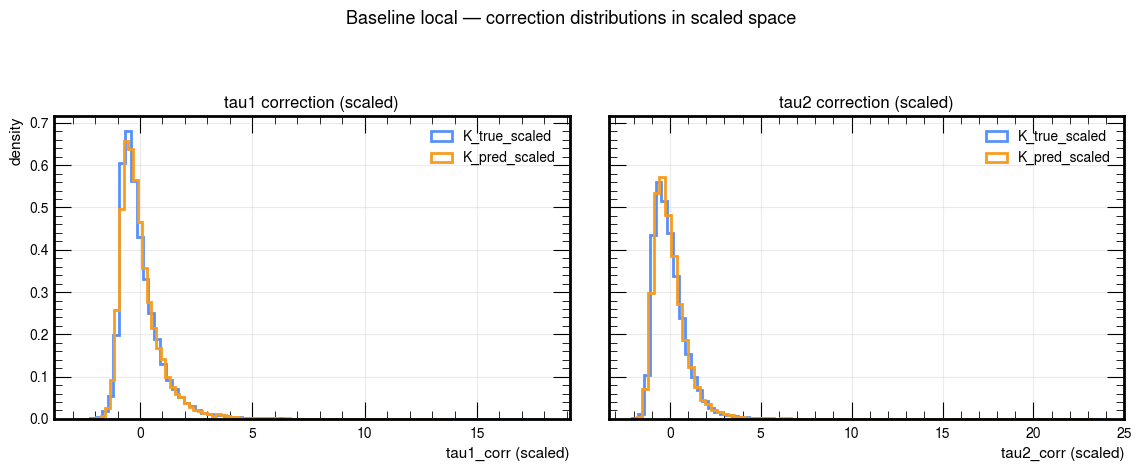

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

# tau1
axes[0].hist(
    df_test_scaled["tau1_corr"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="K_true_scaled",
)

axes[0].hist(
    pred_baseline_scaled["tau1_corr_pred_scaled"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="K_pred_scaled",
)

axes[0].set_xlabel("tau1_corr (scaled)")
axes[0].set_ylabel("density")
axes[0].set_title("tau1 correction (scaled)")
axes[0].legend()


# tau2
axes[1].hist(
    df_test_scaled["tau2_corr"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="K_true_scaled",
)

axes[1].hist(
    pred_baseline_scaled["tau2_corr_pred_scaled"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="K_pred_scaled",
)

axes[1].set_xlabel("tau2_corr (scaled)")
axes[1].set_title("tau2 correction (scaled)")
axes[1].legend()

plt.suptitle("Baseline local — correction distributions in scaled space")
plt.tight_layout()
plt.show()

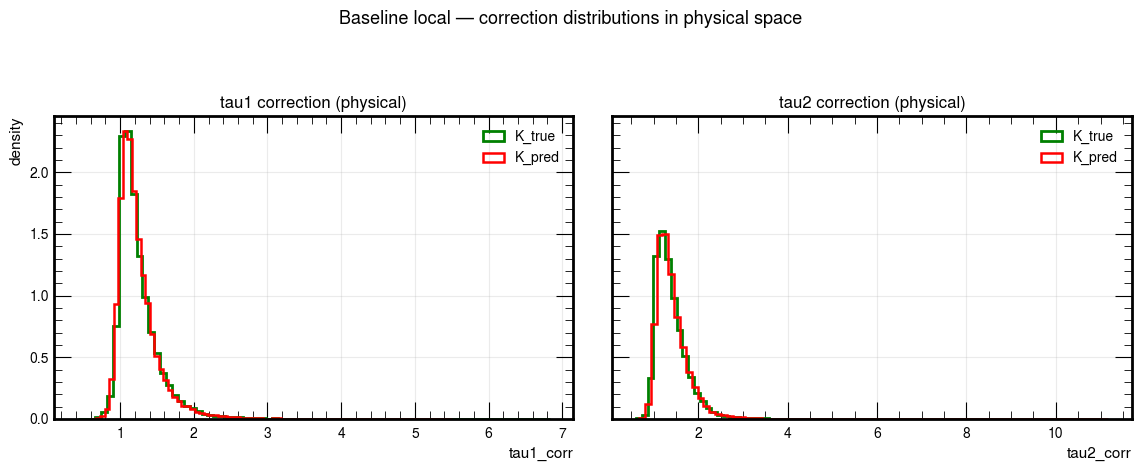

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

# tau1
axes[0].hist(
    df_test_raw["tau1_corr"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="K_true",
    color = 'green',
)

axes[0].hist(
    pred_baseline["tau1_corr_pred"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=1.8,
    label="K_pred",
    color = 'red'
)

axes[0].set_xlabel("tau1_corr")
axes[0].set_ylabel("density")
axes[0].set_title("tau1 correction (physical)")
axes[0].legend()


# tau2
axes[1].hist(
    df_test_raw["tau2_corr"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="K_true",
    color = 'green',
)

axes[1].hist(
    pred_baseline["tau2_corr_pred"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=1.8,
    label="K_pred",
    color = 'red',
)

axes[1].set_xlabel("tau2_corr")
axes[1].set_title("tau2 correction (physical)")
axes[1].legend()

plt.suptitle("Baseline local — correction distributions in physical space")
plt.tight_layout()
plt.show()

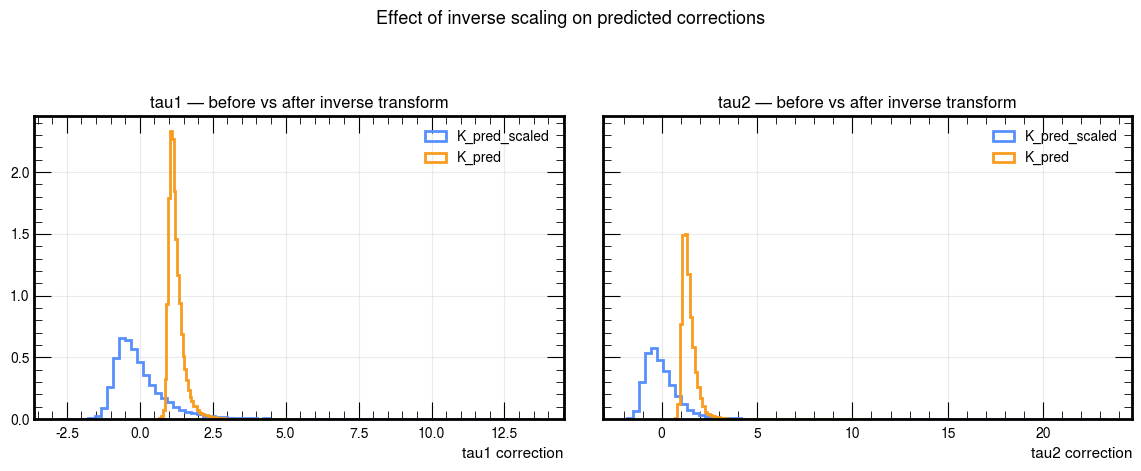

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

# tau1
axes[0].hist(
    pred_baseline_scaled["tau1_corr_pred_scaled"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="K_pred_scaled",
)

axes[0].hist(
    pred_baseline["tau1_corr_pred"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="K_pred",
)

axes[0].set_xlabel("tau1 correction")
axes[0].set_title("tau1 — before vs after inverse transform")
axes[0].legend()

# tau2
axes[1].hist(
    pred_baseline_scaled["tau2_corr_pred_scaled"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="K_pred_scaled",
)

axes[1].hist(
    pred_baseline["tau2_corr_pred"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="K_pred",
)

axes[1].set_xlabel("tau2 correction")
axes[1].set_title("tau2 — before vs after inverse transform")
axes[1].legend()

plt.suptitle("Effect of inverse scaling on predicted corrections")
plt.tight_layout()
plt.show()

In [141]:
# Per un confronto fair, faccio anche il training X_LOCAL__Y_GLOBAL:
# faccio qui la funzione per non rovinare la pipeline

from __future__ import annotations

import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


def prepare_splits_XLOCAL_YGLOBAL(
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
    df_test: pd.DataFrame,
    train_cols: list,
    y_cols: list,
    class_col: str = "class",
    x_scale_cols: list | None = None,
):
    """
    Ad-hoc preparation for mode: X_LOCAL__Y_GLOBAL

    X:
      - local scaling by class (class 0 / class 1)
      - only on x_scale_cols if provided
      - if x_scale_cols is None, scale all train_cols

    Y:
      - global scaling on all events

    Returns:
      df_tr_scaled, df_va_scaled, df_te_scaled, scalers
    """

    if class_col not in df_train.columns:
        raise ValueError(f"Missing class column '{class_col}' in df_train.")
    if class_col not in df_val.columns:
        raise ValueError(f"Missing class column '{class_col}' in df_val.")
    if class_col not in df_test.columns:
        raise ValueError(f"Missing class column '{class_col}' in df_test.")

    for c in train_cols + y_cols:
        if c not in df_train.columns:
            raise ValueError(f"Column '{c}' not found in df_train.")
        if c not in df_val.columns:
            raise ValueError(f"Column '{c}' not found in df_val.")
        if c not in df_test.columns:
            raise ValueError(f"Column '{c}' not found in df_test.")

    if x_scale_cols is None:
        x_scale_cols = list(train_cols)
    else:
        x_scale_cols = list(x_scale_cols)
        missing = [c for c in x_scale_cols if c not in train_cols]
        if missing:
            raise ValueError(f"x_scale_cols not in train_cols: {missing}")

    # copies
    df_tr = df_train.copy()
    df_va = df_val.copy()
    df_te = df_test.copy()

    # -------------------------
    # X_LOCAL
    # -------------------------
    x_scaler = {}
    classes = sorted(df_tr[class_col].unique().tolist())

    for cls in classes:
        mask_tr = df_tr[class_col] == cls
        if mask_tr.sum() == 0:
            raise ValueError(f"No training rows for class {cls}.")

        scaler_cls = StandardScaler()
        scaler_cls.fit(df_tr.loc[mask_tr, x_scale_cols].to_numpy())

        x_scaler[cls] = scaler_cls

        # train
        df_tr.loc[mask_tr, x_scale_cols] = scaler_cls.transform(
            df_tr.loc[mask_tr, x_scale_cols].to_numpy()
        )

        # val
        mask_va = df_va[class_col] == cls
        if mask_va.any():
            df_va.loc[mask_va, x_scale_cols] = scaler_cls.transform(
                df_va.loc[mask_va, x_scale_cols].to_numpy()
            )

        # test
        mask_te = df_te[class_col] == cls
        if mask_te.any():
            df_te.loc[mask_te, x_scale_cols] = scaler_cls.transform(
                df_te.loc[mask_te, x_scale_cols].to_numpy()
            )

    # -------------------------
    # Y_GLOBAL
    # -------------------------
    y_scaler = StandardScaler()
    y_scaler.fit(df_tr[y_cols].to_numpy())

    df_tr.loc[:, y_cols] = y_scaler.transform(df_tr[y_cols].to_numpy())
    df_va.loc[:, y_cols] = y_scaler.transform(df_va[y_cols].to_numpy())
    df_te.loc[:, y_cols] = y_scaler.transform(df_te[y_cols].to_numpy())

    scalers = {
        "mode": "X_LOCAL__Y_GLOBAL",
        "class_col": class_col,
        "x_scale_cols": x_scale_cols,
        "x_scaler": x_scaler,     # dict {0: scaler, 1: scaler}
        "y_scaler": y_scaler,     # global scaler
    }

    return df_tr, df_va, df_te, scalers

In [142]:
df_tr_glob, df_va_glob, df_te_glob, scalers_glob = prepare_splits_XLOCAL_YGLOBAL(
    df_train=df_all_train,
    df_val=df_all_val,
    df_test=df_all_test,
    train_cols=train_cols,
    y_cols=y_cols,
    class_col="class",
)

In [144]:
mode_dir_glob = "../results/prepared_splits/unbalanced/X_LOCAL__Y_GLOBAL"
os.makedirs(mode_dir_glob, exist_ok=True)

df_tr_glob.to_pickle(os.path.join(mode_dir_glob, "train.pkl"))
df_va_glob.to_pickle(os.path.join(mode_dir_glob, "val.pkl"))
df_te_glob.to_pickle(os.path.join(mode_dir_glob, "test.pkl"))

df_all_train.to_pickle(os.path.join(mode_dir_glob, "raw_train.pkl"))
df_all_val.to_pickle(os.path.join(mode_dir_glob, "raw_val.pkl"))
df_all_test.to_pickle(os.path.join(mode_dir_glob, "raw_test.pkl"))

joblib.dump(scalers_glob, os.path.join(mode_dir_glob, "scalers.joblib"))

['../results/prepared_splits/unbalanced/X_LOCAL__Y_GLOBAL/scalers.joblib']

In [145]:
res_glob = training.train_one_mode(
    mode_dir=mode_dir_glob,
    train_cols=train_cols,
    y_cols=y_cols,
    verbose_every=10,
    loss_type="mse",
)

[ep    1] train=1.866348  val=1.678854  best=1.678854  bad=0/30
[ep   10] train=1.176799  val=1.156670  best=1.156670  bad=0/30
[ep   20] train=1.045822  val=1.055359  best=1.049027  bad=3/30
[ep   30] train=1.016304  val=1.028583  best=1.014743  bad=1/30
[ep   40] train=0.977971  val=0.995905  best=0.982000  bad=1/30
[ep   50] train=0.953416  val=0.954815  best=0.946106  bad=1/30
[ep   60] train=0.924686  val=0.916200  best=0.916200  bad=0/30
[ep   70] train=0.897718  val=0.897175  best=0.888960  bad=3/30
[ep   80] train=0.876049  val=0.882834  best=0.875756  bad=1/30
[ep   90] train=0.860506  val=0.854988  best=0.854988  bad=0/30
[ep  100] train=0.845427  val=0.842876  best=0.842876  bad=0/30
[ep  110] train=0.835763  val=0.828045  best=0.828045  bad=0/30
[ep  120] train=0.828345  val=0.826606  best=0.826606  bad=0/30
[ep  130] train=0.816220  val=0.818607  best=0.810465  bad=2/30
[ep  140] train=0.797937  val=0.797255  best=0.797255  bad=0/30
[ep  150] train=0.780250  val=0.785477  

In [147]:
import fm.model as model
importlib.reload(model)

<module 'fm.model' from '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/fm/model.py'>

In [159]:
pred_glob = model.predict_tau_corr_auto_new(
    df=df_test_raw,
    res=res_glob,
    train_cols=train_cols,
    y_cols=y_cols,
)

In [149]:
m_glob = physics.inv_mass_two_taus_corrected_ratio(
    df_all_test["tau1_pt_reco_corrPNet"].to_numpy(),
    df_all_test["tau1_eta"].to_numpy(),
    df_all_test["tau1_phi"].to_numpy(),
    df_all_test["tau1_mass"].to_numpy(),
    df_pred_glob["tau1_corr_pred"].to_numpy(),
    df_all_test["tau2_pt_reco"].to_numpy(),
    df_all_test["tau2_eta"].to_numpy(),
    df_all_test["tau2_phi"].to_numpy(),
    df_all_test["tau2_mass"].to_numpy(),
    df_pred_glob["tau2_corr_pred"].to_numpy(),
)

# Comparison Plot

In [151]:
m_glob_h  = m_glob[mask_h]
m_glob_dy = m_glob[mask_dy]

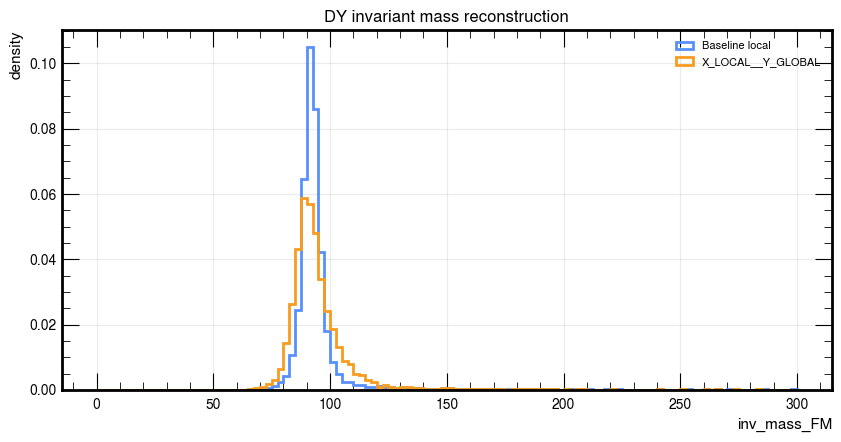

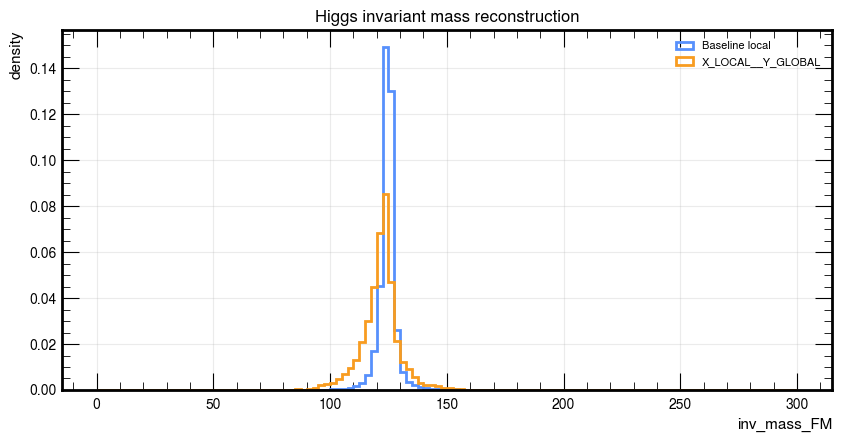

In [153]:
masses_dy_plot = {
    "Baseline local": m_baseline_dy,
    "X_LOCAL__Y_GLOBAL": m_glob_dy,
}

masses_h_plot = {
    "Baseline local": m_baseline_h,
    "X_LOCAL__Y_GLOBAL": m_glob_h,
}

massesPlots.plot_mass_overlay(
    masses_dy_plot,
    title="DY invariant mass reconstruction",
    bins=120,
    range_=(0, 300),
    density=True,
)

massesPlots.plot_mass_overlay(
    masses_h_plot,
    title="Higgs invariant mass reconstruction",
    bins=120,
    range_=(0, 300),
    density=True,
)

In [156]:
pred_glob_scaled = model.predict_tau_corr_scaled_only(
    df=df_test_raw,
    res=res_glob,
    train_cols=train_cols,
    y_cols=y_cols,
)

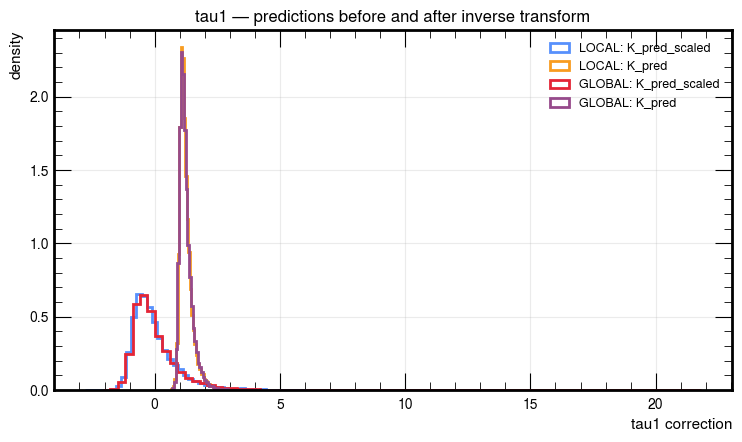

In [161]:
fig, ax = plt.subplots(figsize=(8,5))

ax.hist(
    pred_baseline_scaled["tau1_corr_pred_scaled"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="LOCAL: K_pred_scaled",
)

ax.hist(
    pred_baseline["tau1_corr_pred"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="LOCAL: K_pred",
)

ax.hist(
    pred_glob_scaled["tau1_corr_pred_scaled"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="GLOBAL: K_pred_scaled",
)

ax.hist(
    pred_glob["tau1_corr_pred"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="GLOBAL: K_pred",
)

ax.set_xlabel("tau1 correction")
ax.set_ylabel("density")
ax.set_title("tau1 — predictions before and after inverse transform")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

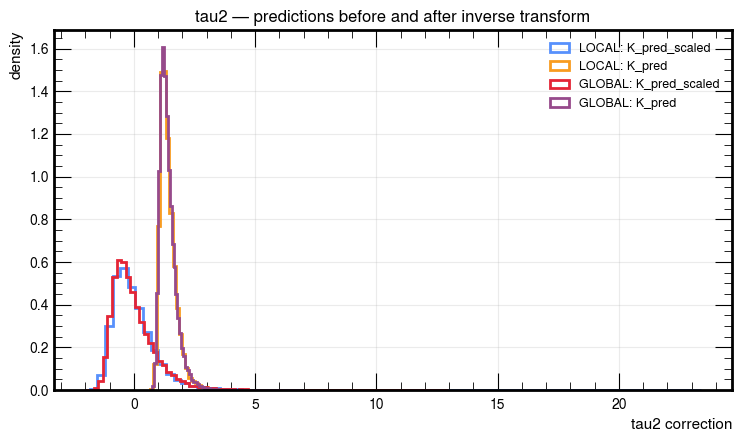

In [160]:
fig, ax = plt.subplots(figsize=(8,5))

ax.hist(
    pred_baseline_scaled["tau2_corr_pred_scaled"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="LOCAL: K_pred_scaled",
)

ax.hist(
    pred_baseline["tau2_corr_pred"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="LOCAL: K_pred",
)

ax.hist(
    pred_glob_scaled["tau2_corr_pred_scaled"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="GLOBAL: K_pred_scaled",
)

ax.hist(
    pred_glob["tau2_corr_pred"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="GLOBAL: K_pred",
)

ax.set_xlabel("tau2 correction")
ax.set_ylabel("density")
ax.set_title("tau2 — predictions before and after inverse transform")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

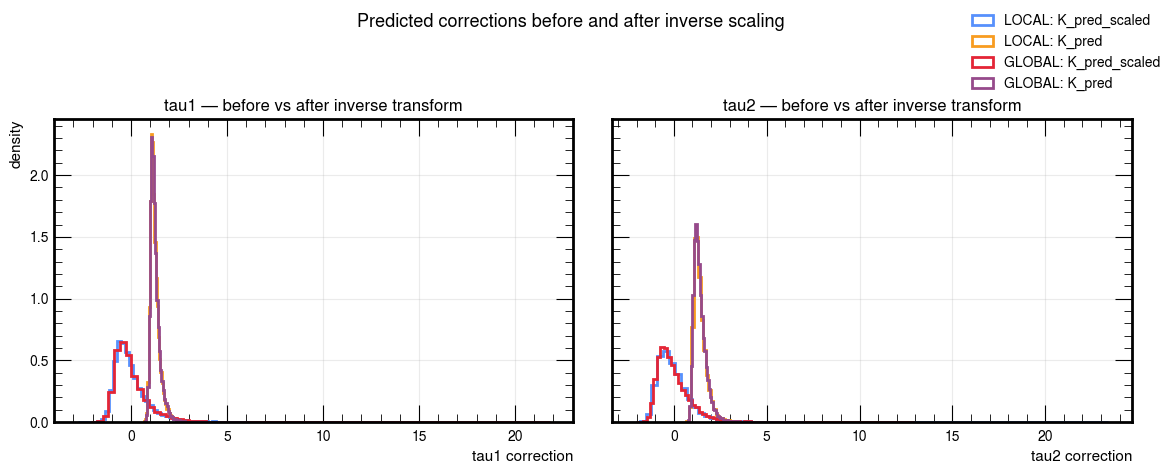

In [163]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

# ======================
# tau1
# ======================
axes[0].hist(
    pred_baseline_scaled["tau1_corr_pred_scaled"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="LOCAL: K_pred_scaled",
)

axes[0].hist(
    pred_baseline["tau1_corr_pred"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="LOCAL: K_pred",
)

axes[0].hist(
    pred_glob_scaled["tau1_corr_pred_scaled"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="GLOBAL: K_pred_scaled",
)

axes[0].hist(
    pred_glob["tau1_corr_pred"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="GLOBAL: K_pred",
)

axes[0].set_xlabel("tau1 correction")
axes[0].set_title("tau1 — before vs after inverse transform")


# ======================
# tau2
# ======================
axes[1].hist(
    pred_baseline_scaled["tau2_corr_pred_scaled"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="LOCAL: K_pred_scaled",
)

axes[1].hist(
    pred_baseline["tau2_corr_pred"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="LOCAL: K_pred",
)

axes[1].hist(
    pred_glob_scaled["tau2_corr_pred_scaled"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="GLOBAL: K_pred_scaled",
)

axes[1].hist(
    pred_glob["tau2_corr_pred"],
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="GLOBAL: K_pred",
)

axes[1].set_xlabel("tau2 correction")
axes[1].set_title("tau2 — before vs after inverse transform")

axes[0].set_ylabel("density")

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.suptitle("Predicted corrections before and after inverse scaling")
plt.tight_layout()
plt.show()

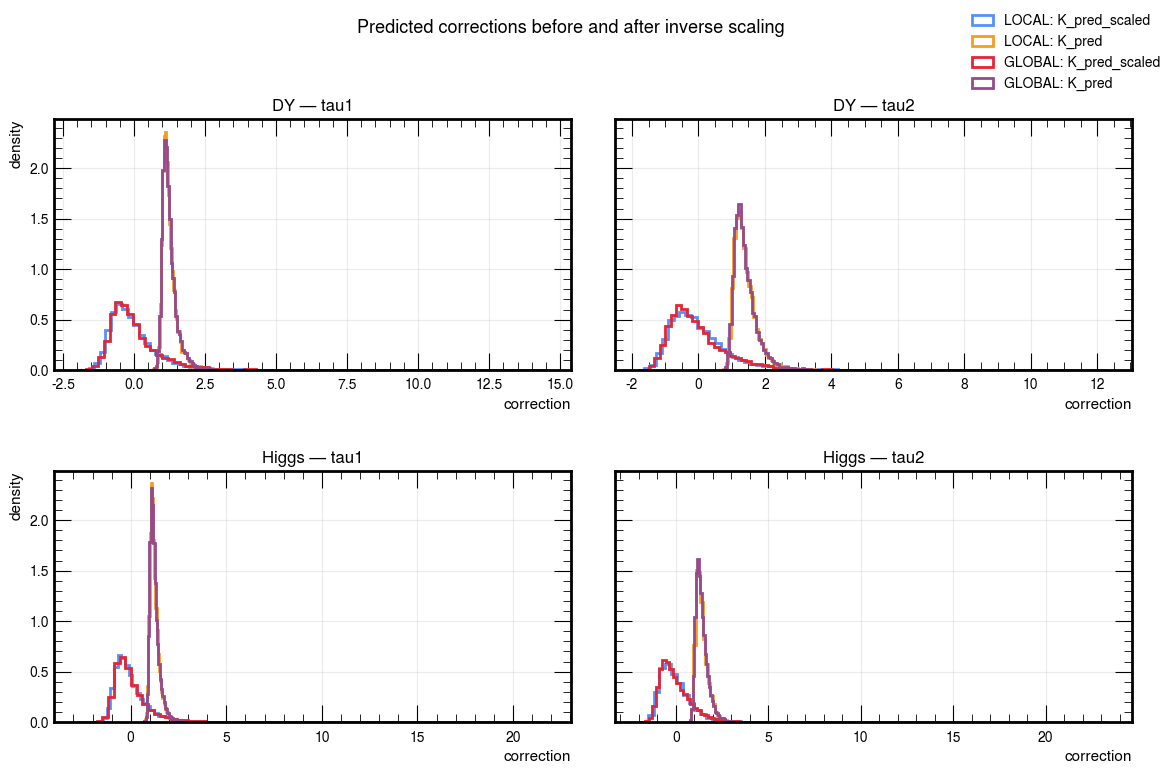

In [194]:
mask_dy = df_all_test["class"] == 0
mask_h  = df_all_test["class"] == 1

fig, axes = plt.subplots(2, 2, figsize=(12,8), sharey=True)

# ======================
# DY
# ======================

# tau1
axes[0,0].hist(pred_baseline_scaled.loc[mask_dy, "tau1_corr_pred_scaled"],
               bins=80, density=True, histtype="step", linewidth=2,
               label="LOCAL: K_pred_scaled")

axes[0,0].hist(pred_baseline.loc[mask_dy, "tau1_corr_pred"],
               bins=80, density=True, histtype="step", linewidth=2,
               label="LOCAL: K_pred")

axes[0,0].hist(pred_glob_scaled.loc[mask_dy, "tau1_corr_pred_scaled"],
               bins=80, density=True, histtype="step", linewidth=2,
               label="GLOBAL: K_pred_scaled")

axes[0,0].hist(pred_glob.loc[mask_dy, "tau1_corr_pred"],
               bins=80, density=True, histtype="step", linewidth=2,
               label="GLOBAL: K_pred")

axes[0,0].set_title("DY — tau1")


# tau2
axes[0,1].hist(pred_baseline_scaled.loc[mask_dy, "tau2_corr_pred_scaled"],
               bins=80, density=True, histtype="step", linewidth=2)

axes[0,1].hist(pred_baseline.loc[mask_dy, "tau2_corr_pred"],
               bins=80, density=True, histtype="step", linewidth=2)

axes[0,1].hist(pred_glob_scaled.loc[mask_dy, "tau2_corr_pred_scaled"],
               bins=80, density=True, histtype="step", linewidth=2)

axes[0,1].hist(pred_glob.loc[mask_dy, "tau2_corr_pred"],
               bins=80, density=True, histtype="step", linewidth=2)

axes[0,1].set_title("DY — tau2")


# ======================
# HIGGS
# ======================

# tau1
axes[1,0].hist(pred_baseline_scaled.loc[mask_h, "tau1_corr_pred_scaled"],
               bins=80, density=True, histtype="step", linewidth=2)

axes[1,0].hist(pred_baseline.loc[mask_h, "tau1_corr_pred"],
               bins=80, density=True, histtype="step", linewidth=2)

axes[1,0].hist(pred_glob_scaled.loc[mask_h, "tau1_corr_pred_scaled"],
               bins=80, density=True, histtype="step", linewidth=2)

axes[1,0].hist(pred_glob.loc[mask_h, "tau1_corr_pred"],
               bins=80, density=True, histtype="step", linewidth=2)

axes[1,0].set_title("Higgs — tau1")


# tau2
axes[1,1].hist(pred_baseline_scaled.loc[mask_h, "tau2_corr_pred_scaled"],
               bins=80, density=True, histtype="step", linewidth=2)

axes[1,1].hist(pred_baseline.loc[mask_h, "tau2_corr_pred"],
               bins=80, density=True, histtype="step", linewidth=2)

axes[1,1].hist(pred_glob_scaled.loc[mask_h, "tau2_corr_pred_scaled"],
               bins=80, density=True, histtype="step", linewidth=2)

axes[1,1].hist(pred_glob.loc[mask_h, "tau2_corr_pred"],
               bins=80, density=True, histtype="step", linewidth=2)

axes[1,1].set_title("Higgs — tau2")


axes[0,0].set_ylabel("density")
axes[1,0].set_ylabel("density")

for ax in axes.flat:
    ax.set_xlabel("correction")

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.suptitle("Predicted corrections before and after inverse scaling")
plt.tight_layout()
plt.show()

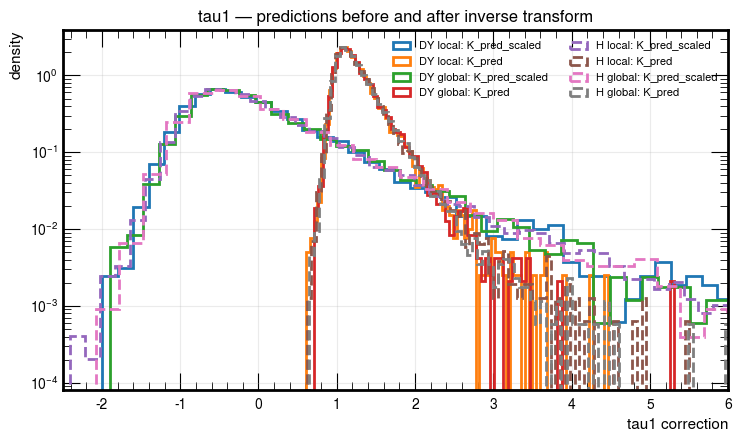

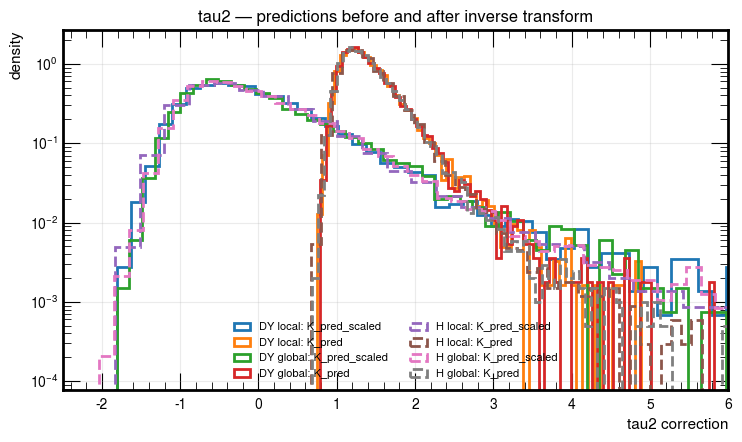

In [202]:
fig, ax = plt.subplots(figsize=(8,5))

colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
]

# DY — solid
ax.hist(
    pred_baseline_scaled.loc[mask_dy, "tau1_corr_pred_scaled"],
    bins=80, density=True, histtype="step", linewidth=2,
    color=colors[0],
    label="DY local: K_pred_scaled"
)

ax.hist(
    pred_baseline.loc[mask_dy, "tau1_corr_pred"],
    bins=80, density=True, histtype="step", linewidth=2,
    color=colors[1],
    label="DY local: K_pred"
)

ax.hist(
    pred_glob_scaled.loc[mask_dy, "tau1_corr_pred_scaled"],
    bins=80, density=True, histtype="step", linewidth=2,
    color=colors[2],
    label="DY global: K_pred_scaled"
)

ax.hist(
    pred_glob.loc[mask_dy, "tau1_corr_pred"],
    bins=80, density=True, histtype="step", linewidth=2,
    color=colors[3],
    label="DY global: K_pred"
)

# Higgs — dashed
ax.hist(
    pred_baseline_scaled.loc[mask_h, "tau1_corr_pred_scaled"],
    bins=80, density=True, histtype="step", linewidth=2,
    linestyle="--",
    color=colors[4],
    label="H local: K_pred_scaled"
)

ax.hist(
    pred_baseline.loc[mask_h, "tau1_corr_pred"],
    bins=80, density=True, histtype="step", linewidth=2,
    linestyle="--",
    color=colors[5],
    label="H local: K_pred"
)

ax.hist(
    pred_glob_scaled.loc[mask_h, "tau1_corr_pred_scaled"],
    bins=80, density=True, histtype="step", linewidth=2,
    linestyle="--",
    color=colors[6],
    label="H global: K_pred_scaled"
)

ax.hist(
    pred_glob.loc[mask_h, "tau1_corr_pred"],
    bins=80, density=True, histtype="step", linewidth=2,
    linestyle="--",
    color=colors[7],
    label="H global: K_pred"
)

ax.set_xlabel("tau1 correction")
ax.set_ylabel("density")
ax.set_title("tau1 — predictions before and after inverse transform")


ax.set_yscale("log")
ax.set_xlim(-2.5, 6)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()








fig, ax = plt.subplots(figsize=(8,5))

# DY — solid
ax.hist(
    pred_baseline_scaled.loc[mask_dy, "tau2_corr_pred_scaled"],
    bins=80, density=True, histtype="step", linewidth=2,
    color=colors[0],
    label="DY local: K_pred_scaled"
)

ax.hist(
    pred_baseline.loc[mask_dy, "tau2_corr_pred"],
    bins=80, density=True, histtype="step", linewidth=2,
    color=colors[1],
    label="DY local: K_pred"
)

ax.hist(
    pred_glob_scaled.loc[mask_dy, "tau2_corr_pred_scaled"],
    bins=80, density=True, histtype="step", linewidth=2,
    color=colors[2],
    label="DY global: K_pred_scaled"
)

ax.hist(
    pred_glob.loc[mask_dy, "tau2_corr_pred"],
    bins=80, density=True, histtype="step", linewidth=2,
    color=colors[3],
    label="DY global: K_pred"
)

# Higgs — dashed
ax.hist(
    pred_baseline_scaled.loc[mask_h, "tau2_corr_pred_scaled"],
    bins=80, density=True, histtype="step", linewidth=2,
    linestyle="--",
    color=colors[4],
    label="H local: K_pred_scaled"
)

ax.hist(
    pred_baseline.loc[mask_h, "tau2_corr_pred"],
    bins=80, density=True, histtype="step", linewidth=2,
    linestyle="--",
    color=colors[5],
    label="H local: K_pred"
)

ax.hist(
    pred_glob_scaled.loc[mask_h, "tau2_corr_pred_scaled"],
    bins=80, density=True, histtype="step", linewidth=2,
    linestyle="--",
    color=colors[6],
    label="H global: K_pred_scaled"
)

ax.hist(
    pred_glob.loc[mask_h, "tau2_corr_pred"],
    bins=80, density=True, histtype="step", linewidth=2,
    linestyle="--",
    color=colors[7],
    label="H global: K_pred"
)

ax.set_xlabel("tau2 correction")
ax.set_ylabel("density")
ax.set_title("tau2 — predictions before and after inverse transform")

ax.set_yscale("log")
ax.set_xlim(-2.5, 6)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

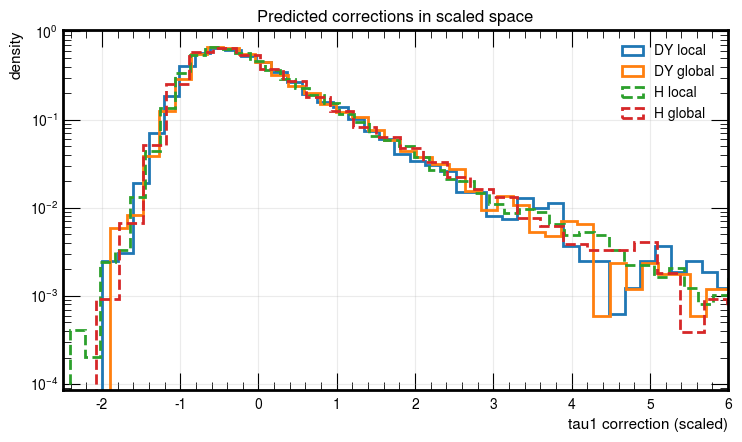

In [203]:
fig, ax = plt.subplots(figsize=(8,5))

# DY
ax.hist(
    pred_baseline_scaled.loc[mask_dy, "tau1_corr_pred_scaled"],
    bins=80, density=True, histtype="step", lw=2,
    color="tab:blue", label="DY local"
)

ax.hist(
    pred_glob_scaled.loc[mask_dy, "tau1_corr_pred_scaled"],
    bins=80, density=True, histtype="step", lw=2,
    color="tab:orange", label="DY global"
)

# Higgs
ax.hist(
    pred_baseline_scaled.loc[mask_h, "tau1_corr_pred_scaled"],
    bins=80, density=True, histtype="step", lw=2,
    linestyle="--", color="tab:green", label="H local"
)

ax.hist(
    pred_glob_scaled.loc[mask_h, "tau1_corr_pred_scaled"],
    bins=80, density=True, histtype="step", lw=2,
    linestyle="--", color="tab:red", label="H global"
)

ax.set_xlabel("tau1 correction (scaled)")
ax.set_ylabel("density")
ax.set_title("Predicted corrections in scaled space")

ax.set_xlim(-2.5, 6)
ax.set_yscale("log")

ax.legend()
plt.tight_layout()
plt.show()

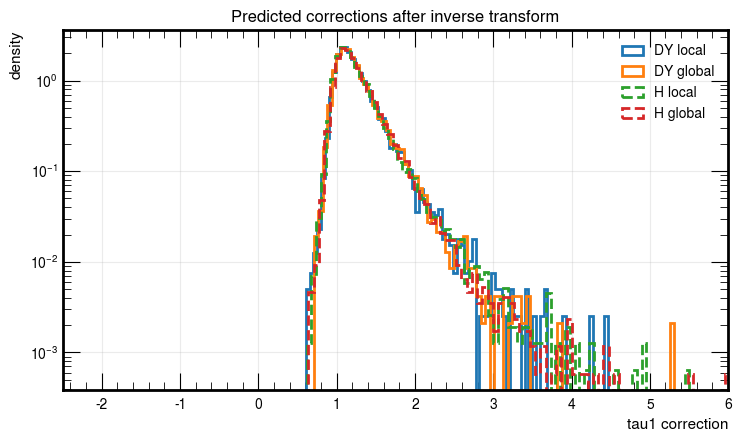

In [204]:
fig, ax = plt.subplots(figsize=(8,5))

# DY
ax.hist(
    pred_baseline.loc[mask_dy, "tau1_corr_pred"],
    bins=80, density=True, histtype="step", lw=2,
    color="tab:blue", label="DY local"
)

ax.hist(
    pred_glob.loc[mask_dy, "tau1_corr_pred"],
    bins=80, density=True, histtype="step", lw=2,
    color="tab:orange", label="DY global"
)

# Higgs
ax.hist(
    pred_baseline.loc[mask_h, "tau1_corr_pred"],
    bins=80, density=True, histtype="step", lw=2,
    linestyle="--", color="tab:green", label="H local"
)

ax.hist(
    pred_glob.loc[mask_h, "tau1_corr_pred"],
    bins=80, density=True, histtype="step", lw=2,
    linestyle="--", color="tab:red", label="H global"
)

ax.set_xlabel("tau1 correction")
ax.set_ylabel("density")
ax.set_title("Predicted corrections after inverse transform")

ax.set_xlim(-2.5, 6)
ax.set_yscale("log")

ax.legend()
plt.tight_layout()
plt.show()

# Loss Plots

In [184]:
runs_dir = "../results/runs_partial_local"

runs = {}

for f in os.listdir(runs_dir):
    if f.endswith(".joblib") and "top25" not in f:
        key = f.replace(".joblib", "")
        runs[key] = joblib.load(os.path.join(runs_dir, f))

In [187]:
for f in sorted(os.listdir(runs_dir)):
    if f.endswith(".joblib") and "top25" not in f:
        path = os.path.join(runs_dir, f)
        res = joblib.load(path)

        print(f"\n===== {f} =====")
        print(type(res))

        if isinstance(res, dict):
            print("keys:", res.keys())
        else:
            print(res)


===== res_top1.joblib =====
<class 'dict'>
keys: dict_keys(['model', 'device', 'train_cols', 'y_cols', 'loss_history', 'df_splits_scaled', 'scalers', 'mode_dir', 'hyperparams'])

===== res_top2.joblib =====
<class 'dict'>
keys: dict_keys(['model', 'device', 'train_cols', 'y_cols', 'loss_history', 'df_splits_scaled', 'scalers', 'mode_dir', 'hyperparams'])

===== res_top3.joblib =====
<class 'dict'>
keys: dict_keys(['model', 'device', 'train_cols', 'y_cols', 'loss_history', 'df_splits_scaled', 'scalers', 'mode_dir', 'hyperparams'])

===== res_top4.joblib =====
<class 'dict'>
keys: dict_keys(['model', 'device', 'train_cols', 'y_cols', 'loss_history', 'df_splits_scaled', 'scalers', 'mode_dir', 'hyperparams'])

===== res_top5.joblib =====
<class 'dict'>
keys: dict_keys(['model', 'device', 'train_cols', 'y_cols', 'loss_history', 'df_splits_scaled', 'scalers', 'mode_dir', 'hyperparams'])

===== res_top52.joblib =====
<class 'dict'>
keys: dict_keys(['model', 'device', 'train_cols', 'y_cols', 

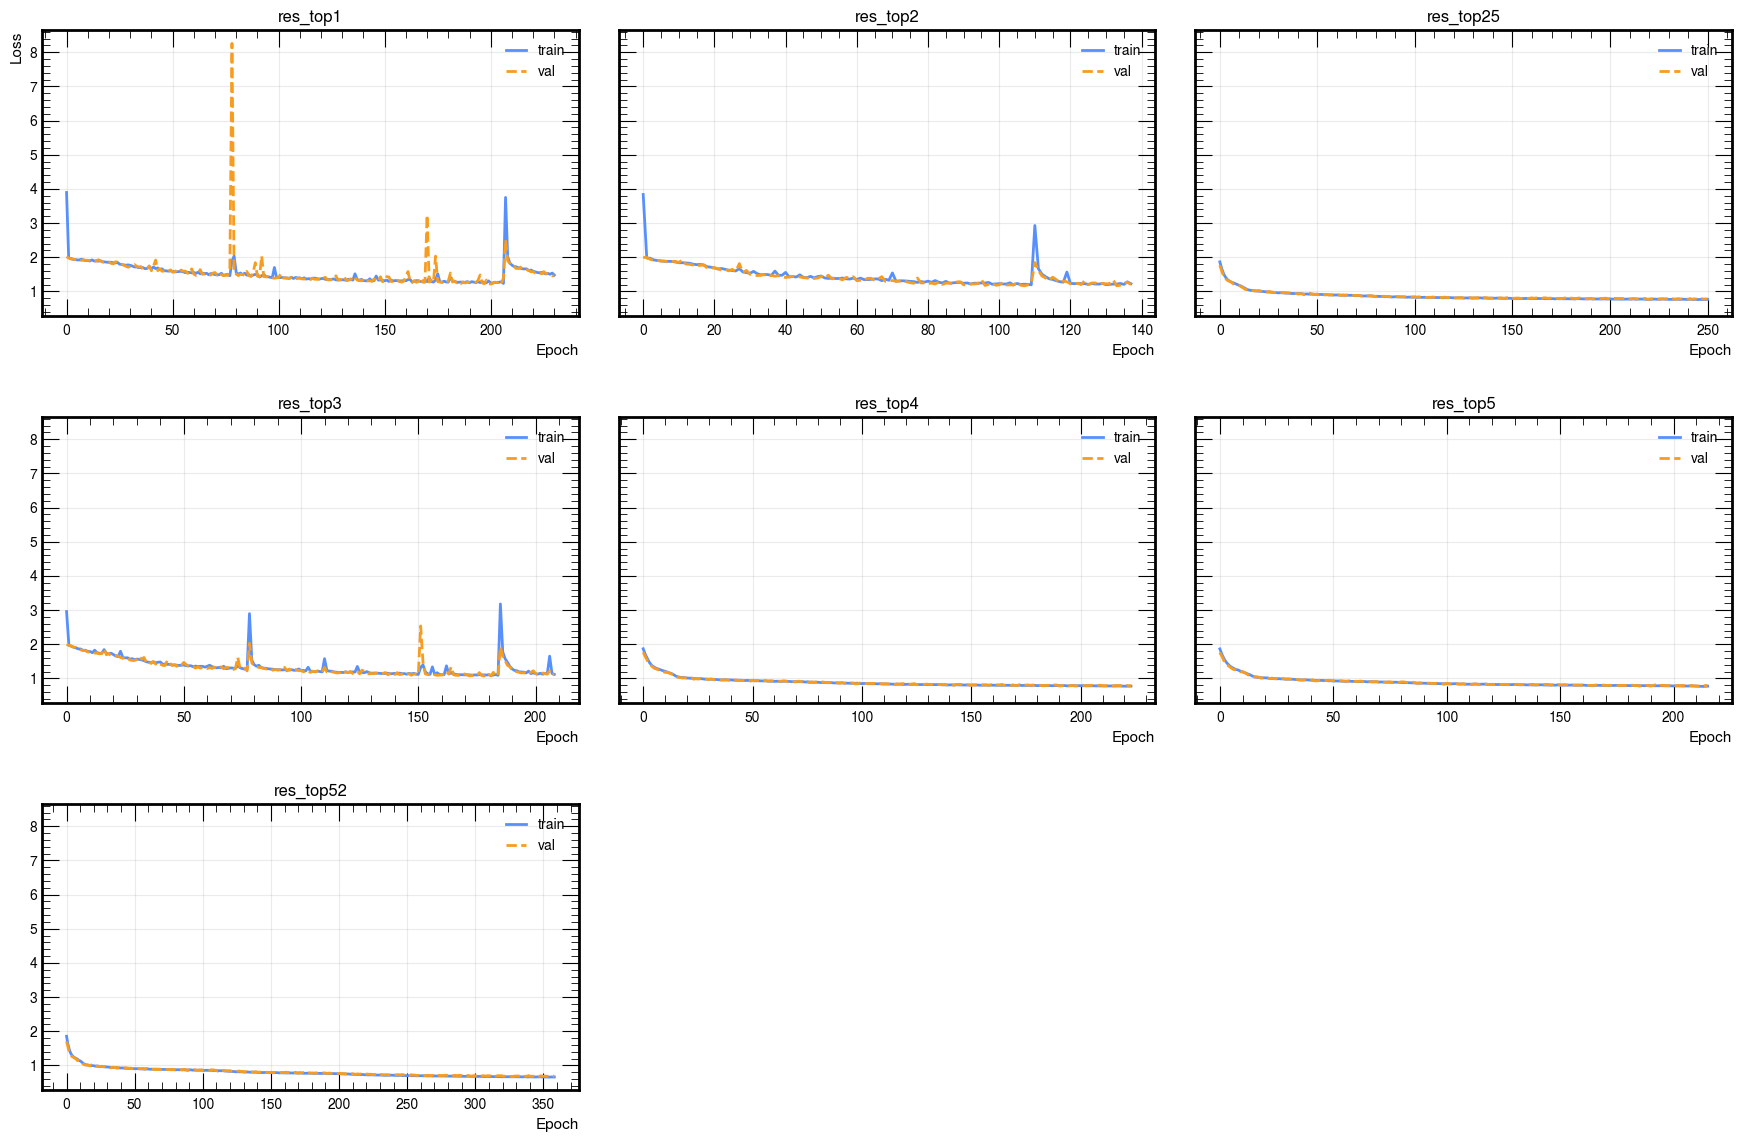

In [192]:
runs = {}

for f in sorted(os.listdir(runs_dir)):
    if f.endswith(".joblib"):
        key = f.replace(".joblib", "")
        runs[key] = joblib.load(os.path.join(runs_dir, f))

n = len(runs)

ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharey=True)

axes = axes.flatten()

for ax, (name, res) in zip(axes, runs.items()):

    hist = res["loss_history"]

    ax.plot(hist["train"], lw=2, label="train")
    ax.plot(hist["val"], lw=2, ls="--", label="val")

    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.legend()

axes[0].set_ylabel("Loss")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()